### Import Libraries

In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Import Dataset


In [303]:
data = pd.read_csv('../Dataset/mymoviedb.csv', engine='python')
data.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


### Basic Analysis

In [304]:
data.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [305]:
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9828 entries, 0 to 9827
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9828 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.2+ KB


(9828, 9)

In [306]:
data['Genre'].value_counts()

Genre
Drama                                   466
Comedy                                  403
Drama, Romance                          248
Horror                                  238
Horror, Thriller                        199
                                       ... 
Animation, Horror, Action, Comedy         1
Comedy, Animation, Family, Adventure      1
Comedy, Crime, Music                      1
Adventure, Documentary                    1
Comedy, Animation, Adventure, Horror      1
Name: count, Length: 2337, dtype: int64

In [307]:
data.duplicated().sum()


np.int64(0)

In [308]:
data.drop(columns=['Overview', 'Original_Language', 'Poster_Url'],inplace = True, errors='ignore')

In [309]:
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller
3,2021-11-24,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9823,1973-10-15,Badlands,13.357,896,7.6,"Drama, Crime"
9824,2020-10-01,Violent Delights,13.356,8,3.5,Horror
9825,2016-05-06,The Offering,13.355,94,5.0,"Mystery, Thriller, Horror"
9826,2021-03-31,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History"


### Convert Vote Average datatype from object to numeric

In [310]:
data['Vote_Average'] = pd.to_numeric(data['Vote_Average'],errors='coerce')
data['Vote_Average'].dtype

dtype('float64')

In [311]:
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller
3,2021-11-24,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9823,1973-10-15,Badlands,13.357,896,7.6,"Drama, Crime"
9824,2020-10-01,Violent Delights,13.356,8,3.5,Horror
9825,2016-05-06,The Offering,13.355,94,5.0,"Mystery, Thriller, Horror"
9826,2021-03-31,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History"


##### Exploration Summary
##### we have a dataframe consisting of 9827 rows and 9 columns.
##### our dataset looks a bit tidy with no NaNs nor duplicated values.
##### Release_Date column needs to be casted into date time and to extract only the year value.
##### Overview, Original_Languege and Poster-Url wouldn't be so useful during analysis, so we'll drop them.
##### there is noticable outliers in Popularity column
##### Vote_Average bettter be categorised for proper analysis.
##### Genre column has comma saperated values and white spaces that needs to be handled and casted into category. Exploration Summary

In [312]:
def Categorise(data,col,labels):
    edges = [
        data[col].describe()['min'],
        data[col].describe()['25%'],
        data[col].describe()['50%'],
        data[col].describe()['75%'],
        data[col].describe()['max']]
    data[col] = pd.cut(data[col],labels=labels, include_lowest=True,bins= edges, duplicates='drop')
    return data;

### Function to make category for rating (vote avg) so that it's easy to understand 

In [313]:
labels =['not_popular','below_average','average','popular']
data = Categorise(data, 'Vote_Average' , labels)
print(data['Vote_Average'].unique())

['popular', 'below_average', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_average' < 'average' < 'popular']


In [314]:
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122,below_average,Thriller
3,2021-11-24,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9823,1973-10-15,Badlands,13.357,896,popular,"Drama, Crime"
9824,2020-10-01,Violent Delights,13.356,8,not_popular,Horror
9825,2016-05-06,The Offering,13.355,94,not_popular,"Mystery, Thriller, Horror"
9826,2021-03-31,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History"


### Datatype conversion from object to dateTime


In [316]:
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122,below_average,Thriller
3,2021-11-24,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9823,1973-10-15,Badlands,13.357,896,popular,"Drama, Crime"
9824,2020-10-01,Violent Delights,13.356,8,not_popular,Horror
9825,2016-05-06,The Offering,13.355,94,not_popular,"Mystery, Thriller, Horror"
9826,2021-03-31,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History"


In [318]:
data['Release_Date'] = pd.to_datetime(data['Release_Date'], errors='coerce')
print(data['Release_Date'].dtype)

datetime64[ns]


In [319]:
data['Release_Date'] = data['Release_Date'].dt.year.astype('Int64')
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_average,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9823,1973,Badlands,13.357,896,popular,"Drama, Crime"
9824,2020,Violent Delights,13.356,8,not_popular,Horror
9825,2016,The Offering,13.355,94,not_popular,"Mystery, Thriller, Horror"
9826,2021,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History"


In [320]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9828 entries, 0 to 9827
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  9827 non-null   Int64   
 1   Title         9828 non-null   object  
 2   Popularity    9827 non-null   float64 
 3   Vote_Count    9827 non-null   object  
 4   Vote_Average  9826 non-null   category
 5   Genre         9826 non-null   object  
dtypes: Int64(1), category(1), float64(1), object(3)
memory usage: 403.4+ KB


In [321]:
data['Vote_Average'].value_counts()

Vote_Average
not_popular      2567
popular          2450
average          2411
below_average    2398
Name: count, dtype: int64

In [322]:
data = pd.DataFrame(data).dropna()
data.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [323]:
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_average,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9823,1973,Badlands,13.357,896,popular,"Drama, Crime"
9824,2020,Violent Delights,13.356,8,not_popular,Horror
9825,2016,The Offering,13.355,94,not_popular,"Mystery, Thriller, Horror"
9826,2021,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History"


##### Now Saperating each Gener for movie

In [324]:
data['Genre'] = data['Genre'].str.split(", ")
data = data.explode('Genre')

In [229]:
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery
...,...,...,...,...,...,...
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama


In [230]:
data['Genre'] = data['Genre'].str.split(", ")
data = data.explode('Genre').reset_index(drop=True) #here it went same but generally without reset_index(drop=True)we will see indexes as 0 0 0 1 1 1 means it will devide by genre but the index remain same for each movie and final index would be 9k and withou reset_index(drop=True) the final index would be 25k or whatever the dataset is and each index would be unique even movie is same like 0 1 2 3 ...
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery
...,...,...,...,...,...,...
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama


In [232]:
data.nunique()

Release_Date     102
Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

## Now we need to answer following qn and visulise

##### 1) What is the most frequent genre of movies released on Netflix?
##### 2) What genres has highest votes?
##### 3) What movie got the highest popularity? what's its genre?
##### 4) What movie got the lowest popularity? what's its genre?
##### 5) Which year has the most filmmed movies?

In [281]:
sns.set_style('whitegrid')

##### 1) What is the most frequent genre of movies released on Netflix?


In [282]:
data['Genre'].value_counts()

Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: count, dtype: int64

In [283]:
data['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

Text(0.5, 0, 'Movie Count')

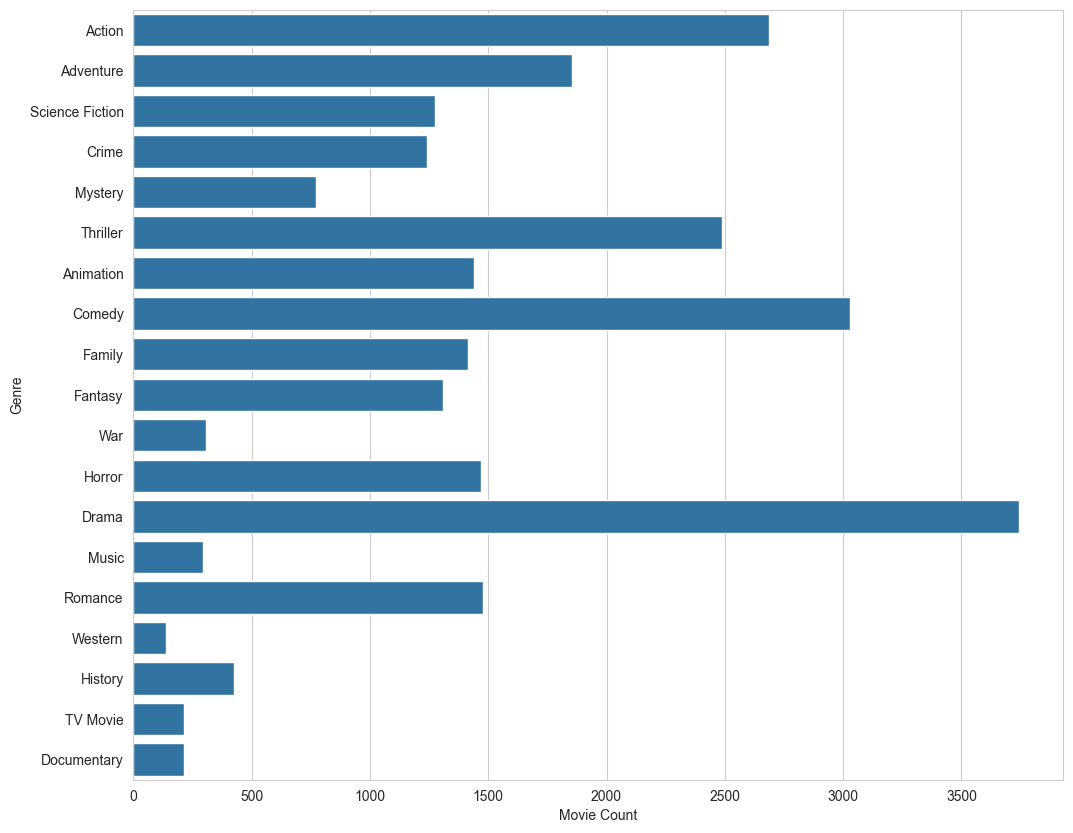

In [284]:
plt.figure(figsize=(12, 10))
sns.countplot(y = data['Genre'])
plt.xlabel('Movie Count')


##### 2) What genres has highest votes?


In [285]:
data['Vote_Average'].value_counts()

Vote_Average
average          6612
popular          6520
below_average    6348
not_popular      6312
Name: count, dtype: int64

In [286]:
data['Vote_Average'].describe()

count       25792
unique          4
top       average
freq         6612
Name: Vote_Average, dtype: object

Text(0.5, 0, 'Movie Vote Category')

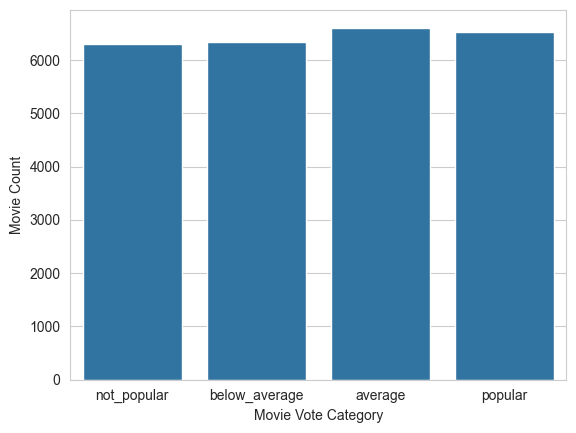

In [287]:
# plt.figure(figsize=(12, 10))
sns.countplot(x = data['Vote_Average'])
plt.ylabel('Movie Count') 
plt.xlabel('Movie Vote Category') 

##### 3) What movie got the highest popularity? what's its genre?


In [288]:
data[data['Popularity'] == data['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


##### 4) What movie got the lowest popularity? what's its genre?


In [289]:
data[data['Popularity'] == data['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


##### 5) Which year has the most filmmed movies?

Text(0.5, 1.0, 'Release Date Column Destribution')

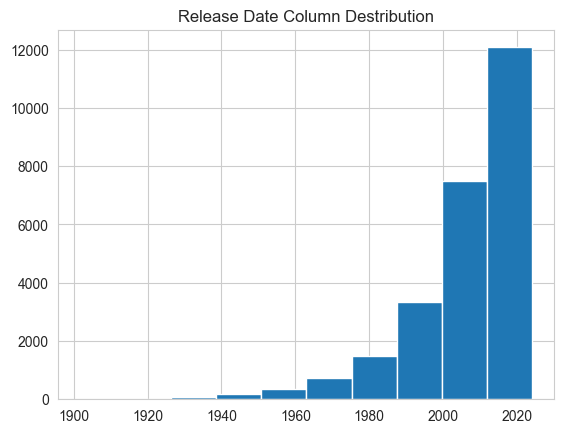

In [291]:
data['Release_Date'].hist()
plt.title('Release Date Column Destribution')

# Conclusion

##### This project was not just about cleaning a movie dataset, but about understanding how raw real-world data is transformed into something useful and analyzable. During preprocessing, issues like missing values, incorrect datatypes, combined genres, and unstructured rating information were handled step by step.

##### One of the most useful parts was converting numerical vote averages into meaningful categories because it made the dataset easier to interpret instead of just looking at decimal ratings. Exploding the genre column also revealed how dominant genres like Drama, Comedy, and Action are across the industry.

##### The analysis showed that preprocessing directly affects the quality of insights we get from data. Small operations like datatype conversion, handling null values, and feature engineering made the dataset much more structured and visualization-ready.

##### Overall, this project helped build practical understanding of Pandas operations, data cleaning workflows, categorical analysis, and exploratory data analysis techniques that are commonly used in real-world data science projects.
